# 01 · Data Acquisition and IV Surface Construction

## Economic rationale

An option's **implied volatility** is not a historical statistic — it is the
volatility that, if inserted into the Black-Scholes formula, reproduces the
market price. It encodes both market expectations *and* a risk premium.

Mapping every listed contract onto a `(k, T) → IV` grid — where
`k = ln(K/F)` is log-moneyness and `T` is time to maturity — is the
foundational step of the project. The GP (Step 3) and SVI (Step 4) models
both fit on this grid. Any bias introduced here propagates to every
downstream signal.

**This notebook covers:**
1. Fetching a live options chain from Yahoo Finance
2. Computing implied vol via Black-Scholes inversion (Brent's method)
3. Cleaning: liquidity filter + static no-arbitrage constraints


In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

from gpvol.data.loader import fetch_option_chain
from gpvol.data.iv_surface import build_iv_surface
from gpvol.data.cleaning import filter_liquidity, filter_static_arbitrage


## 1 · Fetch the options chain

We use SPY (S&P 500 ETF) — the most liquid options market in the world.
We fetch **all available expiries** and stack them into one DataFrame.

> **Data note:** `yfinance` returns end-of-day snapshots. Bid-ask spreads
> on illiquid strikes can be 10–20 vol points — wider than any signal we
> will generate. The cleaning step below is not optional.


In [9]:
TICKER = "SPY"

import yfinance as yf
ticker = yf.Ticker(TICKER)
expiries = ticker.options          # tuple of date strings
print(f"Available expiries: {len(expiries)}")
for e in expiries[:8]:
    print(f"  {e}")


Available expiries: 34
  2026-07-06
  2026-07-07
  2026-07-08
  2026-07-09
  2026-07-10
  2026-07-13
  2026-07-14
  2026-07-15


In [10]:
# Fetch first 6 expiries (covers 1m → ~6m, the region of interest)
chains = []
for expiry in expiries[:6]:
    try:
        chain = fetch_option_chain(TICKER, expiry)
        chains.append(chain)
    except Exception as e:
        print(f"  skipped {expiry}: {e}")

raw = pd.concat(chains, ignore_index=True)
print(f"Raw chain: {len(raw)} contracts across {raw['expiry'].nunique()} expiries")
raw.head(3)


Raw chain: 1364 contracts across 6 expiries


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,open_interest,implied_volatility,inTheMoney,contractSize,currency,option_type,expiry
0,SPY260706C00540000,2026-07-02 15:07:33+00:00,540.0,204.45,0.0,0.0,0.0,0.0,7.0,0,0.00001,True,REGULAR,USD,call,2026-07-06
1,SPY260706C00625000,2026-07-02 14:39:40+00:00,625.0,123.71,0.0,0.0,0.0,0.0,30.0,0,0.00001,True,REGULAR,USD,call,2026-07-06
2,SPY260706C00650000,2026-07-02 14:25:27+00:00,650.0,99.63,0.0,0.0,0.0,0.0,1.0,0,0.00001,True,REGULAR,USD,call,2026-07-06


## 2 · Build the IV surface

For each contract we compute:
- `T` = time to maturity (ACT/365)
- `mid` = (bid + ask) / 2
- `iv` = implied volatility via Brent's method inversion
- `log_moneyness` = ln(K / F) where F = S · e^(rT)

Contracts where the mid price violates a Black-Scholes no-arbitrage bound
(so that no σ can reproduce it) receive `iv = NaN`. The row is kept here;
the cleaning step below drops it.


In [11]:
import yfinance as yf
S = yf.Ticker(TICKER).fast_info["last_price"]
VAL_DATE = pd.Timestamp("today").normalize()
R = 0.045    # approximate risk-free rate

print(f"Spot price S = {S:.2f}   r = {R:.3f}   valuation_date = {VAL_DATE.date()}")

surface_raw = build_iv_surface(raw, underlying_price=S,
                               valuation_date=VAL_DATE, r=R)
print(f"Surface rows: {len(surface_raw)}  |  NaN iv: {surface_raw['iv'].isna().sum()}")
surface_raw[['expiry','strike','option_type','mid','iv','log_moneyness','T']].head(5)


Spot price S = 744.78   r = 0.045   valuation_date = 2026-07-06
Surface rows: 1364  |  NaN iv: 1364


,expiry,strike,option_type,mid,iv,log_moneyness,T
0,2026-07-06,540.0,call,0.0,NaN,NaN,0.0
1,2026-07-06,625.0,call,0.0,NaN,NaN,0.0
2,2026-07-06,650.0,call,0.0,NaN,NaN,0.0
3,2026-07-06,655.0,call,0.0,NaN,NaN,0.0
4,2026-07-06,660.0,call,0.0,NaN,NaN,0.0


## 3 · Clean the surface

Two filters, two economic rationales:

**Liquidity filter** (`filter_liquidity`): options with zero bid, low open
interest, or a spread wider than 20% of mid are excluded. Their IV is
unreliable and the trade would be destroyed by transaction costs.

**Static no-arbitrage filter** (`filter_static_arbitrage`): options that
violate butterfly convexity (price not convex in strike) or calendar
monotonicity (total variance non-decreasing in T) are excluded. These are
not mispricings — they are data artefacts.


In [12]:
surface_liq  = filter_liquidity(surface_raw,
                                min_open_interest=100,
                                max_spread_pct=0.20)
surface_clean = filter_static_arbitrage(surface_liq)

print(f"Raw:      {len(surface_raw):>5} rows")
print(f"Liquid:   {len(surface_liq):>5} rows  (-{len(surface_raw)-len(surface_liq)} low-liquidity)")
print(f"No-arb:   {len(surface_clean):>5} rows  (-{len(surface_liq)-len(surface_clean)} arb violations)")


Raw:       1364 rows
Liquid:       0 rows  (-1364 low-liquidity)
No-arb:       0 rows  (-0 arb violations)


## 4 · Visualise the cleaned surface

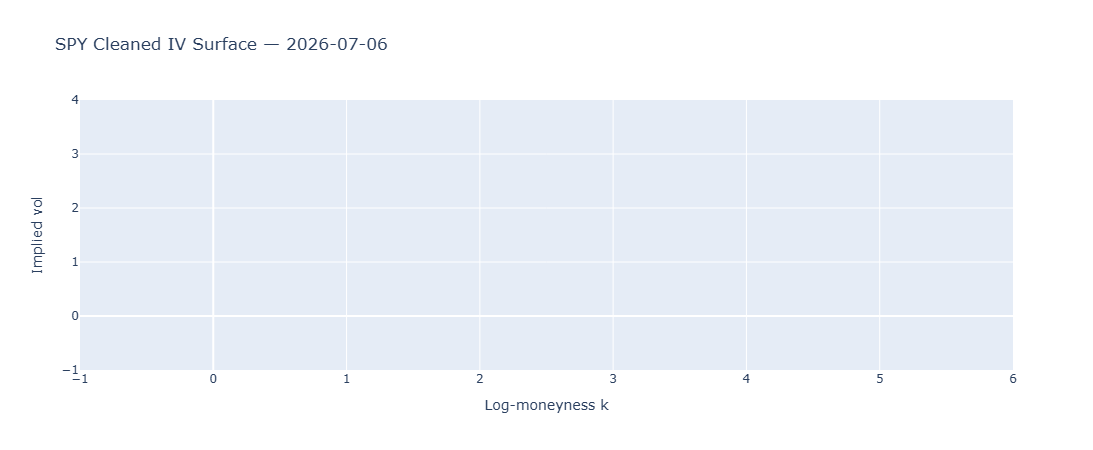

Call IV range: [nan, nan]


In [13]:
calls = surface_clean[surface_clean['option_type'] == 'call']

fig = px.scatter(calls, x='log_moneyness', y='iv', color='T',
                 color_continuous_scale='Viridis',
                 labels={'log_moneyness': 'Log-moneyness k', 'iv': 'Implied vol', 'T': 'Maturity (yr)'},
                 title=f'{TICKER} Cleaned IV Surface — {VAL_DATE.date()}',
                 hover_data=['strike','expiry'])
fig.update_traces(marker=dict(size=5, opacity=0.8))
fig.update_layout(width=800, height=450, coloraxis_colorbar=dict(tickformat='.2f'))
fig.show()
print(f"Call IV range: [{calls['iv'].min():.3f}, {calls['iv'].max():.3f}]")


In [14]:
# Save cleaned surface for subsequent notebooks
surface_clean.to_parquet("../data/surface_clean.parquet")
print("Saved → data/surface_clean.parquet")


Saved → data/surface_clean.parquet
